In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# 목표: 순환 신경망에서 빼놓을 수 없는 핵심기술인 LSTM 과 GRU셀을 사용한 모델을 만들어 봅니다

# 핵심키워드 : LSTM, 셀 상태, GRU

# 핵심 패키지와 함수 : LSTM, GRU,

# 데이터셋 : IMDB 데이터 셋

# LSTM
LSTM (Long Short-Term Memory) : '단기기억'을 '오래' 기억하기

In [5]:
# 순환신경망에서 빼놓을수 없는 핵심기술 LSTM 와 GRU셀 을 사용한 모델

# SimpleRNN 보다 훨~씬 계산이 복잡.  그러나 '성능'이 뛰어남! 순환신경망에서 많이 채택

# 일반적으로 기본 순환층은 '긴 시퀀스'를 학습하기 어렵다.
# 시퀀스가 길수록 순환되는 은닉상태에 담긴 정보가 희석되기 때문
# 따라서 멀리 떨어져 있는 단어 정보를 인식하는데 어려울수 있다.
# 이를 위해 LSTM 과 GRU셀이 등장!

# LSTM 구조

> ppt 참조

# IMDB 데이터 준비

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, random

import tensorflow as tf
from tensorflow import keras

def set_seed(seed = 42):
  tf.keras.utils.set_random_seed(seed)
  # tf.config.experimental.enable_op_determinism()

In [7]:
# 학습모델 저장해볼거다
base_path = r'/content/drive/MyDrive/KDT-2604/dataset'

In [8]:
# 이전 예제 처럼 IMDB  리뷰 데이터를 로드하고 훈련세트와 검증세트로 나눔
from keras.datasets import imdb
from sklearn.model_selection import train_test_split

VOCAB_SIZE = 500  # 사전 크기

(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=VOCAB_SIZE)

train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [9]:
# ↓ 각 샘플의 길이를 100에 맞추고 부족할때는 패딩을 추가
from keras.preprocessing.sequence import pad_sequences

max_len = 100

train_seq = pad_sequences(train_input, maxlen=max_len)
val_seq = pad_sequences(val_input, maxlen=max_len)
test_seq = pad_sequences(test_input, maxlen=max_len)

# ■ LSTM

**tf.keras.layers.LSTM**

https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM

```python
tf.keras.layers.LSTM(
    units,
    activation='tanh',
    recurrent_activation='sigmoid',
    use_bias=True,
    kernel_initializer='glorot_uniform',
    recurrent_initializer='orthogonal',
    bias_initializer='zeros',
    unit_forget_bias=True,
    kernel_regularizer=None,
    recurrent_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    recurrent_constraint=None,
    bias_constraint=None,
    dropout=0.0,  # 셀의 입력에 Dropout 적용
    recurrent_dropout=0.0, # 순환되는 은닉상태에 Dropout 적용
    seed=None,
    return_sequences=False,
    return_state=False,
    go_backwards=False,
    stateful=False,
    unroll=False,
    use_cudnn='auto',
    **kwargs
)
```

In [10]:
# LSTM 셀을 사용한 순환층을 만들어 봅니다
# SimpleRNN 클래스를 LSTM 클래스로 바꾸기만 하면 된다
set_seed(42)
model = keras.Sequential(name = "LSTM_model")

model.add(keras.layers.Input(shape=(max_len,)))  # (100, )
model.add(keras.layers.Embedding(VOCAB_SIZE, 16))
model.add(keras.layers.LSTM(units=8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "LSTM_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
"""
│ lstm (LSTM)                     │ (None, 8)              │           800 │
          # parameter 개수
          # 이전 예제에서 Embedding + SimpleRNN 은 모델 파라미터의 개수가 200개였다.
          # LSTM 셀에는 작은 셀이 4개 있으므로 정확히 x4배가 되어 800개가 됨.

          # ① 입력 parameter  :  16 input x 8 units = 128개
          # ② 은닉상태 parameter : 8 units x 8 units = 64개
          # ③ bias : 8 units 개

          # ④ : ① + ② + ③ = 200개

          # 전체 parameter 는
          #  4 x ④200개 => 800개
          #  ↑ 4 는 LSTM 셀 내의 각 게이트 (입력 게이트, 출력 게이트, 포겟 게이트, 셀 상태 업데이트)
          #    에 해당하는 파라미터의 개수

        ★LSTM의 파라미터 개수★
            => 4gates x units x (units + inputs + 1)
            => ex) 4 x 8 x (8 + 16 + 1) => 800
"""
None

## 훈련🕒

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.5329 - loss: 0.6924 - val_accuracy: 0.5864 - val_loss: 0.6911
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5911 - loss: 0.6898 - val_accuracy: 0.6258 - val_loss: 0.6874
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6326 - loss: 0.6833 - val_accuracy: 0.6562 - val_loss: 0.6765
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6884 - loss: 0.6551 - val_accuracy: 0.7096 - val_loss: 0.6177
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7219 - loss: 0.5891 - val_accuracy: 0.7248 - val_loss: 0.5760
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7383 - loss: 0.5613 - val_accuracy: 0.7404 - val_loss: 0.5555
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7551 - loss: 0.5400 - val_accuracy: 0.7450 - val_loss: 0.5383
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7657 - loss: 0.5220 - val_acc

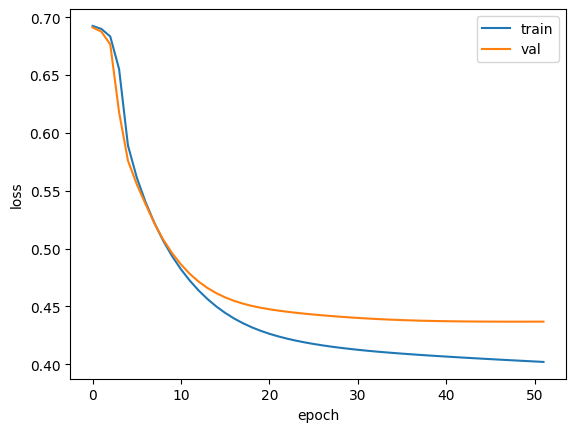

In [12]:
# 모델 컴파일, 학습
# batch_size, epoch 는 동일

rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy',
              metrics=['accuracy'])


checkpoint_cb = keras.callbacks.ModelCheckpoint(
    os.path.join(base_path, 'best-lstm-model.keras'),
    save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history = model.fit(train_seq, train_target, epochs=100, batch_size=64,
                    validation_data=(val_seq, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])


print('🟨 best_epoch: ', early_stopping_cb.best_epoch)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# ■ 순환 층에 드롭아웃 적용

In [13]:
# 완전연결신경망과 CNN 에서는 Dropout 클래스를 사용해서 dropout 을 적용했었다
# 순환층은 '자체적으로 dropout 기능을 제공'

# SimpleRNN, LSTM 클래스에 제공하는 2개의 dropout= 매개변수
#   dropout= : 셀의 '입력'에 dropout 적용
#   recurrent_dropout= : 순환되는 '은닉상태'에 dropout 적용
#                        ※ recurrent_dropout 는 GPU를 통한 훈련 못함..

#  아래 예제에선 dropout= 만 사용함..

In [14]:
set_seed(42)
model = keras.Sequential(name="dropout_model")
model.add(keras.layers.Input(shape=(max_len,))) # (100,)
model.add(keras.layers.Embedding(500, 16))
model.add(keras.layers.LSTM(8, dropout=0.3))  # dropout 30%
model.add(keras.layers.Dense(1, activation='sigmoid'))

## 훈련🕒

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5243 - loss: 0.6926 - val_accuracy: 0.5822 - val_loss: 0.6915
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5724 - loss: 0.6905 - val_accuracy: 0.6132 - val_loss: 0.6887
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6119 - loss: 0.6861 - val_accuracy: 0.6472 - val_loss: 0.6818
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6540 - loss: 0.6719 - val_accuracy: 0.6948 - val_loss: 0.6517
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6944 - loss: 0.6183 - val_accuracy: 0.7168 - val_loss: 0.5888
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7179 - loss: 0.5801 - val_accuracy: 0.7316 - val_loss: 0.5663
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7362 - loss: 0.5571 - val_accuracy: 0.7452 - val_loss: 0.5449
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7523 - loss: 0.5352 - val_acc

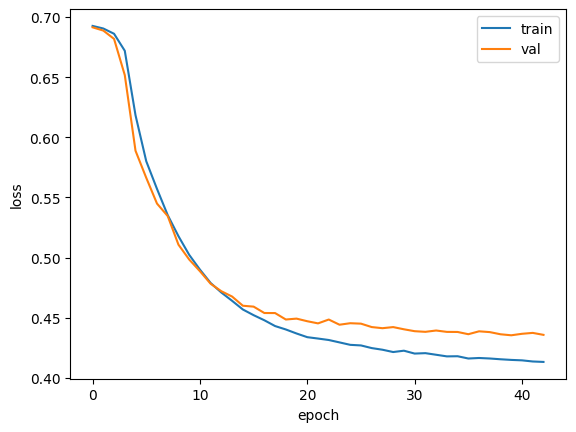

In [15]:
# 이전과 동일한 조건으로 훈련해보자 (저장 파일명만 변경)
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy',
               metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    os.path.join(base_path, 'best-dropout-model.keras'),
    save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history = model.fit(train_seq, train_target, epochs=100, batch_size=64,
                     validation_data=(val_seq, val_target),
                     callbacks=[checkpoint_cb, early_stopping_cb])

print('🟨 best_epoch: ', early_stopping_cb.best_epoch)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# ■ 순환층 2개 연결하기
### 순환층 연결시 주의!
- 순환층의 은닉상태는 샘플의 마지막 스텝에 대한 은닉 상태만 다음층으로 전달한다
- 그러나, 순환층을 쌓게 되면 모든 순환층에는 순차 데이터가 필요하다.
- 따라서
    - 앞쪽의 순환층은 '모든 타임스텝'에 대한 은닉상태를 출력해야 하고,
    - 마지막 순환층만 '마지막 타임스텝의 은닉상태'를 출력해야 한다

※ ppt 설명 참조

<img src="https://www.dropbox.com/scl/fi/q7b6o7pn3nqr6d11usvpe/LSTM01.jpg?rlkey=0rdunfnq364sptgh56f2m2i2w&st=47m4n188&dl=1" width=700>

## return_sequences=True
모든 타임스텝에 대한 은닉상태 출력 (2차원 출력)

In [16]:
# keras의 순환층에서 '모든타임스텝의 은닉상태' 를 출력하려면 마지막을 제외한 모든 순환층에
# return_sequences=True 를 지정해준다
set_seed(42)

model = keras.Sequential(name="2RNN-model")
model.add(keras.layers.Input(shape=(max_len,)))  # (100,)
model.add(keras.layers.Embedding(500, 16))
model.add(keras.layers.LSTM(8, dropout=0.3, return_sequences=True))
model.add(keras.layers.LSTM(8, dropout=0.3))
model.add(keras.layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "2RNN-model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 8)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,353 (36.54 KB)

 Trainable params: 9,353 (36.54 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
"""
│ embedding_2 (Embedding)         │ (None, 100, 16)        │         8,000 │


│ lstm_2 (LSTM)                   │ (None, 100, 8)         │           800 │
  # 출력 shape
  #   첫번째 LSTM층이 모든 타임스탭(100개)의 은닉 상태를 출력하기 떄문에
  #   출력 크기 (100, 8)로 출련됨 (2차원)

  # parameter 개수
  #   => 4gates x units x (units + inputs + 1)
  #   =>    4   x   8   x (8    +   16    + 1) => 800

│ lstm_3 (LSTM)                   │ (None, 8)              │           544 │
  # 출력크기 : (8, )

  # parameter 개수
      => 4gates x units x (units + inputs + 1)
      =>   4    x    8  x (8   + 8   + 1) => 544

│ dense_2 (Dense)                 │ (None, 1)              │             9 │

"""
None

## 훈련🕒

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5052 - loss: 0.6931 - val_accuracy: 0.4996 - val_loss: 0.6931
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5311 - loss: 0.6926 - val_accuracy: 0.5768 - val_loss: 0.6923
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5765 - loss: 0.6911 - val_accuracy: 0.6344 - val_loss: 0.6893
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6157 - loss: 0.6843 - val_accuracy: 0.6578 - val_loss: 0.6744
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6619 - loss: 0.6484 - val_accuracy: 0.6946 - val_loss: 0.6040
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7042 - loss: 0.5834 - val_accuracy: 0.7250 - val_loss: 0.5573
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7311 - loss: 0.5482 - val_accuracy: 0.7412 - val_loss: 0.5341
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7506 - loss: 0.5251 - 

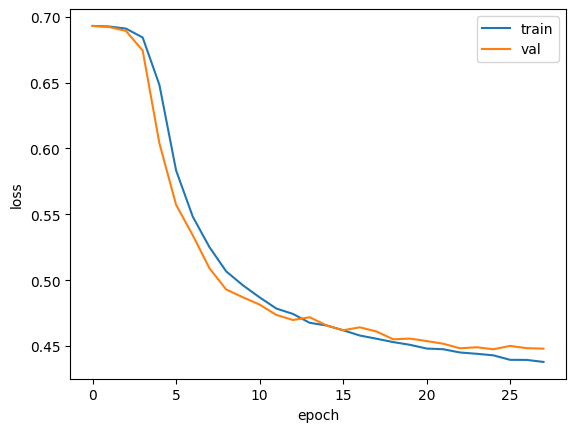

In [18]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy',
               metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint(
          os.path.join(base_path, 'best-2rnn-model.keras'),
          save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history = model.fit(train_seq, train_target, epochs=100, batch_size=64,
                     validation_data=(val_seq, val_target),
                     callbacks=[checkpoint_cb, early_stopping_cb])

print('🟨 best_epoch: ', early_stopping_cb.best_epoch)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# ■ GRU 신경망
Gated Recurrent Unit

https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU

```python
tf.keras.layers.GRU(
    units,
    activation='tanh',
    recurrent_activation='sigmoid',
    use_bias=True,
    kernel_initializer='glorot_uniform',
    recurrent_initializer='orthogonal',
    bias_initializer='zeros',
    kernel_regularizer=None,
    recurrent_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    recurrent_constraint=None,
    bias_constraint=None,
    dropout=0.0,
    recurrent_dropout=0.0,
    seed=None,
    return_sequences=False,
    return_state=False,
    go_backwards=False,
    stateful=False,
    unroll=False,
    reset_after=True,
    use_cudnn='auto',
    **kwargs
)
```

In [21]:
# LSTM 클래스를  GRU 로 바뀐거 이외에는 이전 모델과 동일함
set_seed(42)

model = keras.Sequential(name="gru-model")

model.add(keras.layers.Input(shape=(max_len,))) # (100,)
model.add(keras.layers.Embedding(500, 16))
model.add(keras.layers.GRU(units=8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "gru-model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 8)              │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,633 (33.72 KB)

 Trainable params: 8,633 (33.72 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
"""
Model: "gru-model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #
=================================================================
 embedding_3 (Embedding)     (None, 100, 16)           8000

 gru (GRU)                   (None, 8)                 624

     # paramer 개수
     # GRU 셀에는 3개의 작은셀이 있다
     # 작은셀에는 '입력'과 '은닉상태(h)' 에 곱하는 weight 와 bias 가 있다.
     # '입력'에 곱하는 weight 는 16 * 8 = 128개
     # '은닉상태'에 곱하는 weight 는 8 * 8 = 64개
     # bias 가 뉴런마다 하나씩 있으므로 8개
     #  모두 더하면 128 + 64 + 8 = 200개
     #  이런 작은 셀이 3개 있으므로 200 * 3 => 600개 !   (그런데 결과는 624개?)

     # TF GRU 는 내부적으로 작은 셀마다 하나의 bias 가 추가된다
     #    작은셀3개 x 8개 units = 24개

 dense_3 (Dense)             (None, 1)                 9

=================================================================
Total params: 8,633
Trainable params: 8,633
Non-trainable params: 0
_________________________________________________________________
"""
None

## 훈련🕒

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5089 - loss: 0.6927 - val_accuracy: 0.5288 - val_loss: 0.6922
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5642 - loss: 0.6906 - val_accuracy: 0.5708 - val_loss: 0.6899
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5901 - loss: 0.6874 - val_accuracy: 0.5866 - val_loss: 0.6862
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6022 - loss: 0.6823 - val_accuracy: 0.5970 - val_loss: 0.6805
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6158 - loss: 0.6745 - val_accuracy: 0.6120 - val_loss: 0.6718
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6306 - loss: 0.6627 - val_accuracy: 0.6234 - val_loss: 0.6586
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6488 - loss: 0.6448 - val_accuracy: 0.6504 - val_loss: 0.6377
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6747 - loss: 0.6157 - val_accu

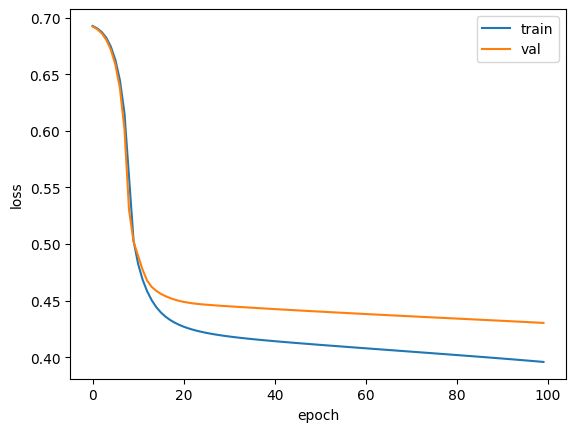

In [23]:
# Colab CPU 기준 8분 48초
# Colab GPU 기준 2분 18초

# GRU 셀을 사용한 순환신경망 훈련
# 훈련방법은 이전과 동일

rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy',
               metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    os.path.join(base_path, 'best-gru-model.keras'),
    save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history = model.fit(train_seq, train_target, epochs=100, batch_size=64,
                     validation_data=(val_seq, val_target),
                     callbacks=[checkpoint_cb, early_stopping_cb])

print('🟨 best_epoch: ', early_stopping_cb.best_epoch)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [24]:
# 가장 좋았던 2개의 순환층을 쌓은 모델을 다시 로드하여 테스트 세트에 대한 성능을 확인해봅니다

# 테스트 세트를 훈련세트와 동일한 방식으로 변환합니다.
test_seq = pad_sequences(test_input, maxlen=max_len)

rnn_model = keras.models.load_model(os.path.join(base_path, 'best-2rnn-model.keras'))

rnn_model.evaluate(test_seq, test_target)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7931 - loss: 0.4448


[0.4447886049747467, 0.7930799722671509]

# ■ 양방향 LSTM
Bidirectional-LSTM, Bi-LSTM
RNN 이나 LSTM 은 일반 신경망과 다르게 시퀀스 또는 시계열 데이터 처리에 특화되어 은닉층에서 과거의 정보를 기억할 수 있습니다.  그러나, 순환 신경망의 구조적 특성상 데이터가 **'입력 순'** 으로 처리되기 때문에 이전 시점의 정보만 활용할 수 밖에 없는 단점이 존재합니다.  문장이 길어 질수록(시퀀스가 길어질수록) 성능이 저하될 수 밖에 없습니다. 다음 예문을 봅시다

> ios 앱 <u>[   ]</u>은 맥북이 필요합니다

> ios 앱 <u>개발</u>은 맥북이 필요합니다

한국어를 사용하는 우리에겐 어렵지 않게 빈칸에 들어가는 단어를 유추해낼수 있다.  그러나 일반적인 RNN 이나 LSTM 에서 순차적으로 입력되는 시퀀스를 통해 앞에 입력된 데이터인 'ios' 와 '앱' 이라는 단어만 가지고 빈칸에 들어갈 '개발' 이라는 단어를 유추해 내기엔 정보가 매우 부족하다.

문장 **앞부분보단, 뒷부분에 중요한 정보**가 존재하기 때문입니다.

따라서! 자연어 처리에서 입력 데이터의 '정방향' 처리만큼 **'역방향'** 처리도 중요합니다!

**양방향 LSTM (Bidirectional LSTM)** 은 기존 LSTM 계측에 역방향으로 처리하는  LSTM 계층을 하나 더 추가해 양방향에서 문장의 패턴을 분석할수 있도록 구성되어 있습니다.  입력 문장을 양방향에서 처리하므로 시퀀스 길이가 길어진다 하더라도 정보 손실 없이 처리가 가능


**양방향 LSTM 구조**

![](https://blog.kakaocdn.net/dn/ySdrH/btrZrwllBAV/T6RqmCYAkavMJ1iZ2gTi80/img.png)

## Bidirectional
**tf.keras.layers.Bidirectional**
- RNN 에 적용하는 양방향 (bidirectional) wrapper
- https://www.tensorflow.org/api_docs/python/tf/keras/layers/Bidirectional
- Bidirectional 로 설정할 RNN layer 는 **return_sequences=True**: 모든 time step 에서 출력을 반환해야 하므로 설정해야 한다

```python
tf.keras.layers.Bidirectional(
    layer,
    merge_mode='concat',
    weights=None,
    backward_layer=None,
    **kwargs
)
```





## TimeDistributed
**tf.keras.layers.TimeDistributed**
- 각 time step 에서 출력된 output 을 내부에 선언해준 레이어와 연결시켜주는 역할
- TimeDistributed 또한 Wrapper 다 (Wrapper 상속객체)
- https://www.tensorflow.org/api_docs/python/tf/keras/layers/TimeDistributed
- 출력 형태는 (batch_size, time_steps, num_classes)

```python
tf.keras.layers.TimeDistributed(
    layer, **kwargs
)
```



양방향 LSTM 모델을 정의할때 주의점!
- 정방향, 역방향 LSTM 계측 모두 출력값을 연결해야 하기 때문에, return_sequences= 인자를 반드시 True 로 해야 함.
- 또한 Dense 계층을 TimeDistributed 래퍼를 사용해 3차원 텐서를 입력받을수 있게 확장해야 한다

## 양방향 LSTM 모델 정의

In [ ]:
# ① 양방향 LSTM 모델 정의
# 생성된 시퀀스 데이터를 학습하기 위한 LSTM 계층을 정의
# LSTM 계층을 양방향으로 설정하기 위해 Bidirectional 래퍼(wrapper) 사용


In [19]:
from tensorflow.keras.layers import Bidirectional, TimeDistributed, Flatten, \
                                Input, LSTM, Embedding, Dense
set_seed(42)

model = keras.Sequential(name="bidirectional_lstm")

model.add(Input(shape=(max_len,))) # (100, )
model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=16))

model.add(Bidirectional(LSTM(8, dropout=0.3, return_sequences=True)))
model.add(TimeDistributed(Dense(1, activation='sigmoid')))
model.add(Flatten())

model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "bidirectional_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 16)        │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 1)         │            17 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,718 (37.96 KB)

 Trainable params: 9,718 (37.96 KB)

 Non-trainable params: 0 (0.00 B)

## 훈련🕒

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.5029 - loss: 0.7302 - val_accuracy: 0.4954 - val_loss: 0.6935
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5128 - loss: 0.6928 - val_accuracy: 0.5150 - val_loss: 0.6926
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5153 - loss: 0.6926 - val_accuracy: 0.5226 - val_loss: 0.6925
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5163 - loss: 0.6923 - val_accuracy: 0.5274 - val_loss: 0.6923
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5237 - loss: 0.6920 - val_accuracy: 0.5328 - val_loss: 0.6920
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5252 - loss: 0.6916 - val_accuracy: 0.5374 - val_loss: 0.6917
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5326 - loss: 0.6913 - val_accuracy: 0.5416 - val_loss: 0.6914
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5390 - loss: 0.6908 -

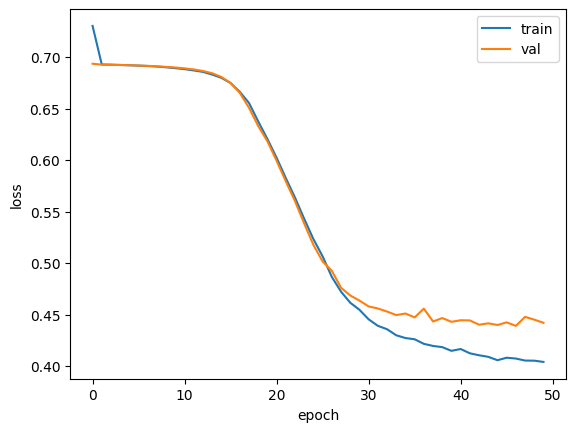

In [20]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy',
               metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint(
          os.path.join(base_path, 'best-biLSTM-model.keras'),
          save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history = model.fit(train_seq, train_target, epochs=100, batch_size=64,
                     validation_data=(val_seq, val_target),
                     callbacks=[checkpoint_cb, early_stopping_cb])

print('🟨 best_epoch: ', early_stopping_cb.best_epoch)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()